In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Training K-Nearest Neighbors (KNN) Model ---")

# Define the parameter grid for GridSearchCV
# We'll search for the best 'k' (n_neighbors) value
param_grid = {'n_neighbors': list(range(1, 21))}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to evaluate the model based on accuracy
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("\nPerforming Grid Search Cross-Validation to find the best K...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best K (n_neighbors) found by GridSearchCV
best_k = grid_search.best_params_['n_neighbors']
print(f"\nBest K (n_neighbors) found by GridSearchCV: {best_k}")

# Get the best estimator (KNN model with the best K)
best_knn_model = grid_search.best_estimator_

print("\n--- Evaluating the Best KNN Model ---")

# Make predictions on the test set using the best model
y_pred = best_knn_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set with best K ({best_k}): {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



--- Training K-Nearest Neighbors (KNN) Model ---

Performing Grid Search Cross-Validation to find the best K...


NameError: name 'X_train' is not defined

Iris dataset loaded successfully!
First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  

Checking for missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Dataset with target names:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0        

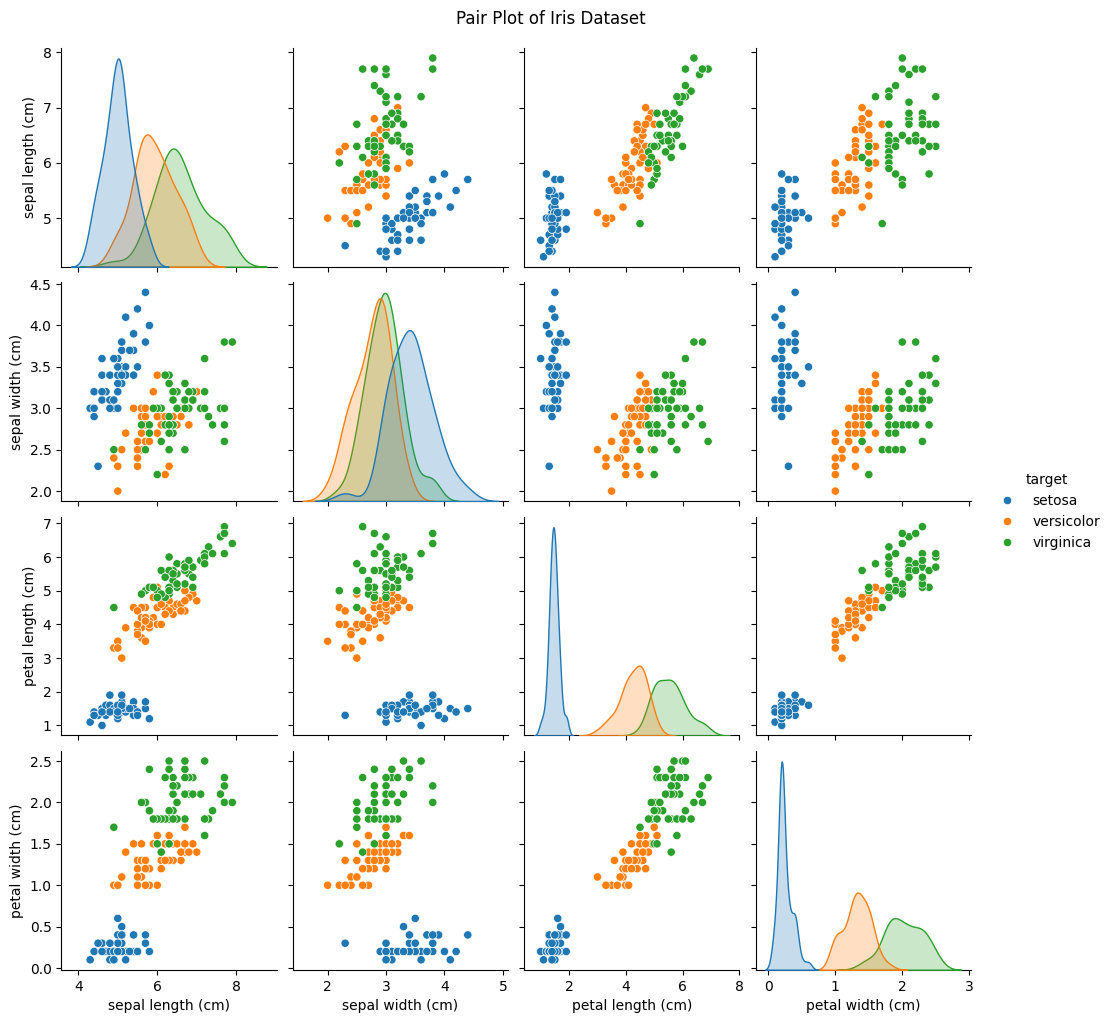


Correlation matrix:


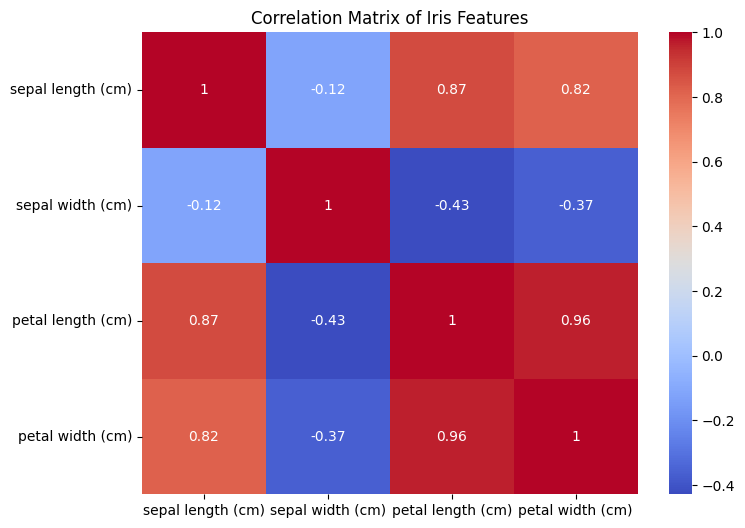


Data split into training and testing sets:
X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)

Example of X_train head:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
98                 5.1               2.5                3.0               1.1
68                 6.2               2.2                4.5               1.5
19                 5.1               3.8                1.5               0.3
143                6.8               3.2                5.9               2.3
99                 5.7               2.8                4.1               1.3

Example of y_train head:
98     versicolor
68     versicolor
19         setosa
143     virginica
99     versicolor
Name: target, dtype: object


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Import the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

print("Iris dataset loaded successfully!")
print("First 5 rows of the dataset:")
print(df.head())

# 2. Clean it (Iris dataset is generally clean, but we'll check for missing values)
print("\nChecking for missing values:")
print(df.isnull().sum())

# We can convert target to meaningful names
df['target'] = df['target'].map({i: name for i, name in enumerate(iris['target_names'])})
print("\nDataset with target names:")
print(df.head())

# 3. Explore it
print("\nDescriptive statistics:")
print(df.describe())

print("\nData types and non-null values:")
df.info()

# Visualize the data
print("\nGenerating pair plot for exploration...")
sns.pairplot(df, hue='target')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()

# Correlation matrix
print("\nCorrelation matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Iris Features')
plt.show()

# 4. Split it into training data and testing data
X = df.drop('target', axis=1) # Features
y = df['target']             # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nExample of X_train head:")
print(X_train.head())
print("\nExample of y_train head:")
print(y_train.head())


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Decision Tree Classifier with Tuning ---")

# Define parameter grid for Decision Tree
# max_depth controls the depth of the tree (pruning)
# min_samples_leaf also controls pruning
dt_param_grid = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10, 15],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV for Decision Tree
dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Performing Grid Search Cross-Validation for Decision Tree...")
dt_grid_search.fit(X_train, y_train)

# Get the best Decision Tree model
best_dt_model = dt_grid_search.best_estimator_
print(f"Best parameters for Decision Tree: {dt_grid_search.best_params_}")
print(f"Best cross-validation accuracy for Decision Tree: {dt_grid_search.best_score_:.4f}")

# Evaluate the best Decision Tree model on the test set
dt_y_pred = best_dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print(f"Decision Tree Test Set Accuracy: {dt_accuracy:.4f}")
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_y_pred))

print("\n--- Random Forest Classifier with Tuning ---")

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV for Random Forest
rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Performing Grid Search Cross-Validation for Random Forest...")
rf_grid_search.fit(X_train, y_train)

# Get the best Random Forest model
best_rf_model = rf_grid_search.best_estimator_
print(f"Best parameters for Random Forest: {rf_grid_search.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {rf_grid_search.best_score_:.4f}")

# Evaluate the best Random Forest model on the test set
rf_y_pred = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Test Set Accuracy: {rf_accuracy:.4f}")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))



--- Decision Tree Classifier with Tuning ---
Performing Grid Search Cross-Validation for Decision Tree...
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
Best cross-validation accuracy for Decision Tree: 0.9524
Decision Tree Test Set Accuracy: 0.9778
Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


--- Random Forest Classifier with Tuning ---
Performing Grid Search Cross-Validation for Random Forest...
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best cross-validation accuracy for Random Forest: 0.961